# Aarhus Universitet &mdash; SWMAL E25  
## Assignment O3
### Gruppe 10

---

### Members

| Name                         | Student ID   |
|------------------------------|--------------|
| Per Hindbo Clausen           | 202007348    |
| Mads Kampmann Elkjær         | 202209870    |
| Daniel Them                  | 201809623    |
| Frederick Lykkegaard Nielsen | 202207768    |

---

### Hand-in Date

**15/11-2025**

## L07: Convolutional Neural Networks (CNNs)

### Introduction to CNNs

Convolutional Neural Networks (CNNs) are neural networks designed for images. They learn features directly from pixels by stacking **convolution** layers (small filters scanning the image to detect local patterns), optional **pooling** layers (downsampling to make features more robust to small shifts), and a small **classifier head** that outputs class scores. This builds a hierarchy of features: edges and textures in early layers, shapes and parts deeper in the network.

A **convolution layer** applies several learnable kernels across the height and width of the image (and across channels), producing **feature maps** that light up when the corresponding pattern is present. Pooling (e.g., max pooling) reduces spatial size while keeping the strongest activations, lowering computation and adding a bit of translation tolerance. 

---

**Sources** 

- [CS231n: Convolutional Neural Networks](https://cs231n.github.io/convolutional-networks)
- [TensorFlow tutorial: Convolutional Neural Network (CNN)](https://www.tensorflow.org/tutorials/images/cnn)
- [Keras example: Simple MNIST convnet](https://cs231n.github.io/convolutional-networks)


### Our experiments towards the end-goal of reaching 'a high accuracy' 

We started with the official Keras MNIST convnet recipe and small tweaks. Baseline (Conv32→Pool→Dropout → Conv64→Pool→Dropout → Dense128→Dropout→Softmax) already reached ~99.2% test accuracy. Increasing epochs beyond 10 gave tiny gains but more time. We tried with a heavier dropout (≥0.6) but a lighter (0.25/0.5) worked best. We also tried switching optimizer from **Adam** which converged fast and strong to **SGD** which needed more epochs to get the same result. Adding more filters (e.g., 64/128) didn’t noticeably help on MNIST.


### How we used '_generalization_' in our setup


We kept 10% of the training set as a **validation split** (Keras `validation_split=0.1`) to monitor generalization and tune minor choices (epochs, dropout). Final numbers are from the **held-out test** set (10k images). K-fold wasn’t necessary here given dataset size and the clean signal.


### Producing a '_learning-curve_' that illustrates the drop in cost- or increase in score-function

We plotted training vs. validation **loss** and **accuracy** across epochs. Both curves improved smoothly and stayed close, with validation slightly better early on—consistent with healthy training and no overfitting.



### Documentation of the final CNN setup, 

<pre style="white-space:pre;overflow-x:auto;line-height:normal;font-family:Menlo,'DejaVu Sans Mono',consolas,'Courier New',monospace">┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃<span style="font-weight: bold"> Layer (type)                    </span>┃<span style="font-weight: bold"> Output Shape           </span>┃<span style="font-weight: bold">       Param # </span>┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (<span style="color: #0087ff; text-decoration-color: #0087ff">Conv2D</span>)                 │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">26</span>, <span style="color: #00af00; text-decoration-color: #00af00">26</span>, <span style="color: #00af00; text-decoration-color: #00af00">32</span>)     │           <span style="color: #00af00; text-decoration-color: #00af00">320</span> │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (<span style="color: #0087ff; text-decoration-color: #0087ff">MaxPooling2D</span>)    │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">13</span>, <span style="color: #00af00; text-decoration-color: #00af00">13</span>, <span style="color: #00af00; text-decoration-color: #00af00">32</span>)     │             <span style="color: #00af00; text-decoration-color: #00af00">0</span> │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (<span style="color: #0087ff; text-decoration-color: #0087ff">Dropout</span>)               │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">13</span>, <span style="color: #00af00; text-decoration-color: #00af00">13</span>, <span style="color: #00af00; text-decoration-color: #00af00">32</span>)     │             <span style="color: #00af00; text-decoration-color: #00af00">0</span> │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (<span style="color: #0087ff; text-decoration-color: #0087ff">Conv2D</span>)               │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">11</span>, <span style="color: #00af00; text-decoration-color: #00af00">11</span>, <span style="color: #00af00; text-decoration-color: #00af00">64</span>)     │        <span style="color: #00af00; text-decoration-color: #00af00">18,496</span> │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (<span style="color: #0087ff; text-decoration-color: #0087ff">MaxPooling2D</span>)  │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">5</span>, <span style="color: #00af00; text-decoration-color: #00af00">5</span>, <span style="color: #00af00; text-decoration-color: #00af00">64</span>)       │             <span style="color: #00af00; text-decoration-color: #00af00">0</span> │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dropout</span>)             │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">5</span>, <span style="color: #00af00; text-decoration-color: #00af00">5</span>, <span style="color: #00af00; text-decoration-color: #00af00">64</span>)       │             <span style="color: #00af00; text-decoration-color: #00af00">0</span> │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (<span style="color: #0087ff; text-decoration-color: #0087ff">Flatten</span>)               │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">1600</span>)           │             <span style="color: #00af00; text-decoration-color: #00af00">0</span> │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (<span style="color: #0087ff; text-decoration-color: #0087ff">Dense</span>)                   │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">128</span>)            │       <span style="color: #00af00; text-decoration-color: #00af00">204,928</span> │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dropout</span>)             │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">128</span>)            │             <span style="color: #00af00; text-decoration-color: #00af00">0</span> │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (<span style="color: #0087ff; text-decoration-color: #0087ff">Dense</span>)                 │ (<span style="color: #00d7ff; text-decoration-color: #00d7ff">None</span>, <span style="color: #00af00; text-decoration-color: #00af00">10</span>)             │         <span style="color: #00af00; text-decoration-color: #00af00">1,290</span> │
└─────────────────────────────────┴────────────────────────┴───────────────┘
</pre>


 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)
 
 Non-trainable params: 0 (0.00 B)

### Discussion on our iterations towards the end-goal and other findings we had

On MNIST a compact CNN plus simple normalization is enough for ~99% accuracy. Adam outperformed SGD with minimal tuning. Extra depth/width and heavy regularization were unnecessary. The small model converged quickly and generalized well. The learning curves matched this with no widening gap and a steadily falling loss.



### Conclusion.

With a standard Keras convnet, normalization, and a small validation split, we reached **~99.2% test accuracy** on MNIST in ~10 epochs. The model is simple, fast, and stable. To acchive further gains we would likely have to use ensembling or more aggressive tuning.

### __9. Build an CNN via the Keras API and try to achieve the highest possible accuracy on MNIST.__

We use a this example as template:

**Source:** [Keras MNIST ConvNet example](https://keras.io/examples/vision/mnist_convnet/)


### Setup

In [8]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

tf.random.set_seed(42)

# Load data
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Scale to [0,1] and add channel dim
x_train = (x_train.astype("float32") / 255.0)[..., None]
x_test  = (x_test.astype("float32")  / 255.0)[..., None]

print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)


(60000, 28, 28, 1) (60000,) (10000, 28, 28, 1) (10000,)


We build a small CNN with two blocks of Conv2D→ReLU→MaxPool and Dropout to reduce overfitting, then flatten the features and use a Dense layer (128 units) before a softmax output over 10 classes. We compile it with Adam and `sparse_categorical_crossentropy` since our labels are integers, and call `model.summary()` to check the layer shapes and parameter counts. This follows the standard Keras MNIST convnet pattern.


In [9]:
from tensorflow.keras import layers, models

num_classes = 10
input_shape = (28, 28, 1)

model = models.Sequential(
    [
        layers.Input(shape=input_shape),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax"),
    ]
)

model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

The feature maps get smaller and deeper as they pass through the conv blocks, then flatten to 1,600 features and feed a dense head to 10 classes, with about 225k trainable parameters (mostly in the dense layer).

We train for 10 epochs with batch size 128 and keep 10% of the training data as validation to monitor generalization while fitting; after training, we evaluate on the held-out test set and print test accuracy.


In [10]:
epochs = 10
batch_size = 128

history = model.fit(
    x_train, y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.1,
    verbose=2
)

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")


Epoch 1/10
422/422 - 8s - 19ms/step - accuracy: 0.8793 - loss: 0.3826 - val_accuracy: 0.9795 - val_loss: 0.0700
Epoch 2/10
422/422 - 7s - 17ms/step - accuracy: 0.9606 - loss: 0.1294 - val_accuracy: 0.9865 - val_loss: 0.0484
Epoch 3/10
422/422 - 7s - 17ms/step - accuracy: 0.9718 - loss: 0.0962 - val_accuracy: 0.9888 - val_loss: 0.0383
Epoch 4/10
422/422 - 7s - 17ms/step - accuracy: 0.9768 - loss: 0.0773 - val_accuracy: 0.9900 - val_loss: 0.0351
Epoch 5/10
422/422 - 7s - 17ms/step - accuracy: 0.9781 - loss: 0.0724 - val_accuracy: 0.9898 - val_loss: 0.0345
Epoch 6/10
422/422 - 7s - 17ms/step - accuracy: 0.9810 - loss: 0.0624 - val_accuracy: 0.9917 - val_loss: 0.0314
Epoch 7/10
422/422 - 7s - 17ms/step - accuracy: 0.9824 - loss: 0.0569 - val_accuracy: 0.9918 - val_loss: 0.0302
Epoch 8/10
422/422 - 7s - 17ms/step - accuracy: 0.9843 - loss: 0.0519 - val_accuracy: 0.9920 - val_loss: 0.0311
Epoch 9/10
422/422 - 7s - 17ms/step - accuracy: 0.9842 - loss: 0.0501 - val_accuracy: 0.9927 - val_loss:

Validation accuracy climbs to ~99.3% with steadily falling loss, and the final test accuracy is ~99.2%, which is typical for this CNN on MNIST and indicates good generalization without obvious overfitting.

We plot learning curves: training vs. validation loss and accuracy across epochs.


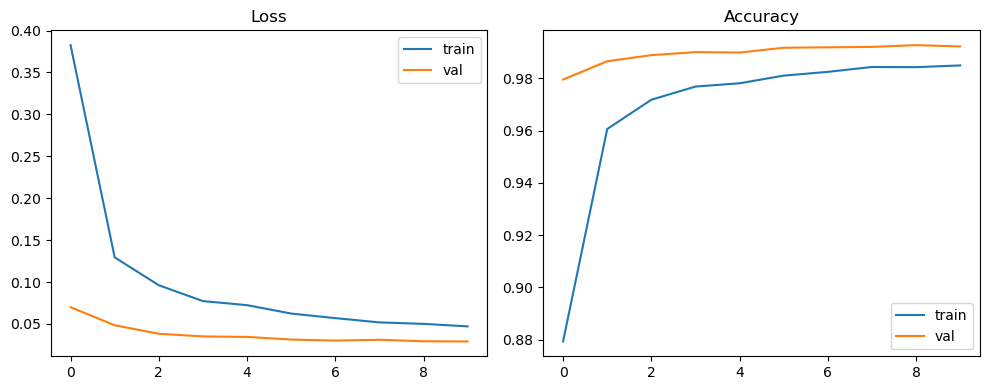

In [11]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss"); plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("Accuracy"); plt.legend()

plt.tight_layout(); plt.show()


Validation loss drops smoothly and stays just below training loss (dropout makes train noisier), while both accuracies rise and stay close—validation even slightly higher early on. This points to good fit and no overfitting; the model converged well within 10 epochs.

## L08: Learning Curves

### The Generalization Error, Over- and Underfitting, Early Stopping, and Optimal Capacity

<img src="https://itundervisning.ase.au.dk/SWMAL/L08/Figs/dl_generalization_error.png" alt="WARNING: could not get image from server." style="height:500px">


### Qa) The Generalization Error


* training/generalization error, 
* underfit/overfit zone, 
* optimal capacity, 
* generalization gab, 
* and the two axes: x/capacity, y/error.

The graph in figure 5.3 displays a blue and a green curve. The blue dashed line shows the amount of errors in the training and shows how well the model fits the training data. The green curve is the generalization error (test error), which is how well it performs on unseen data.
The X-axis on the graph shows the capacity of the model and the Y-axis shows error.

The graph is split into 3 zones. A underfitting zone, optimal capacity and an overfitting zone.

The underfitting zone in the left side shows that the capacity is very low, which indicates that the model is simple. Training error is high and test error is also very high. This underfitting is where the model haven't picked up on the data pattern just yet. It could need more training.

The overfitting zone on the right side whows the training error is low, and test error is much higher. This overfitting is when the model fits the training data perfectly. When test error is high, it cannot really predict on new data very well. It probably memoizes the data set.

The optimal capacity at the red line, is when the model knows just enough to know the pattern of the training data, but not enough to have it memoized. 

The generalization gap is the space between training error and test/generalization error in the graph. Its defined by $Generalization_gap = Test_error - Training_error$.
It shows how worse our model performs on unseen data, compared to the data that was used to train the model. If the gap is small, then the model generalizes well, which means that it learned the patterns in the training data. If the gap is large, then it is overfitting, meaning that it probably has memoized the training data.

The two axes, x and y, is respectively the model capacity and the error.
Model capacity measures how complex or flexible our model is. When we move along the axis, the model get more capacity, which means more layers, parameters and fit the training data more precisely. But as mentioned before, the model could also begin to memorize the data.
Left is the simple model, right is the genius model that remembers everything.
The Y-axis is error. The higher the error rate is, the more wrong it is. Lower is better. As the capacity increases, the training errors decreases. In the start our model learns the data and the patterns, but if we continue the model overfits and errors starts to increase again.


[Source (chatGPT)](https://chatgpt.com/share/69047c07-f5a0-8008-8dbf-83f04627ebe7)

### Qb Learning Curves

The `MyLinReg` class is from the last assignment. The LossHistory has been implemented below

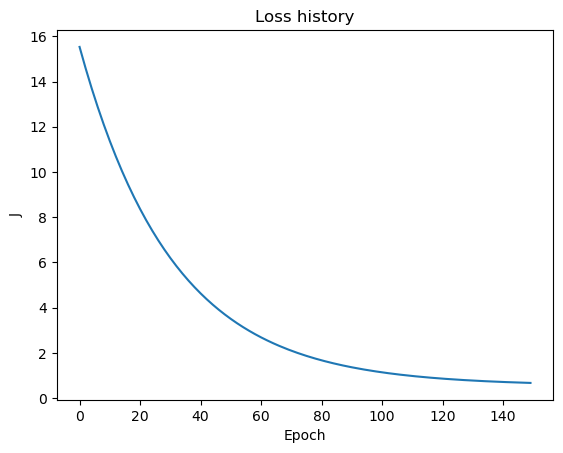

OK


In [12]:
import numpy as np

class MyLinReg():
    def __init__(self, eta0=0.05, max_iter=300, tol=1e-8, n_iter_no_change=30, verbose=True,
                 solver="gd", batch_size=1, shuffle=True, random_state=None):
        self.eta0 = eta0
        self.max_iter = max_iter
        self.tol = tol
        self.n_iter_no_change = n_iter_no_change
        self.verbose = verbose
        self.solver = solver
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.random_state = random_state
        self.w_ = None
        self.best_cost = np.inf
        self.no_improve_count = 0
        self.errors_ = []

    def __str__(self):
        return f"MyLinReg(eta0={self.eta0}, max_iter={self.max_iter})"
    
    def _add_bias(self, X): # bias function where the column of 1's is added to X
        return np.c_[np.ones((X.shape[0], 1)), X]

    def _cost(self, X, y, w): # cost function 
        error = X @ w - y
        return 0.5 * np.sum(error ** 2)

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y).ravel()
        Xb = self._add_bias(X)
        n_samples, n_features = Xb.shape
        self.w_ = np.zeros(n_features)

        rng = np.random.default_rng(self.random_state)

        # Batch gradient descent - minimizes the cost function over all samples
        if self.solver == "gd":
            for i in range(self.max_iter):
                error = Xb @ self.w_ - y
                grad = Xb.T @ error / n_samples
                J = 0.5 * np.mean(error ** 2)
                self.errors_.append(J)                    

                if J + self.tol < self.best_cost:
                    self.best_cost = J
                    self.no_improve_count = 0
                else:
                    self.no_improve_count += 1
                
                if self.no_improve_count >= self.n_iter_no_change:
                    if self.verbose:
                        print(f"Early stopping at iter {i + 1}: J={J:.6f}")
                    break

                self.w_ -= self.eta0 * grad # Gradient descent step

                if self.verbose and (i % 10 == 0 or i == self.max_iter - 1):
                    print(f"Iter {i+1:03d}: J={J:.6f}, |grad|={np.linalg.norm(grad):.4f}")

        # Stochastic gradient descent
        else:
            bs = max(1, int(self.batch_size))
            idx = np.arange(n_samples)
            for epoch in range(self.max_iter):
                if self.shuffle:
                    rng.shuffle(idx)
                for s in range(0, n_samples, bs):
                    j = idx[s:s+bs]
                    err_j = Xb[j] @ self.w_ - y[j]
                    grad_j = Xb[j].T @ err_j
                    self.w_ -= self.eta0 * grad_j

                J = 0.5 * np.sum((Xb @ self.w_ - y) ** 2)
                self.errors_.append(J) # log cost (once per epoch)

                if J + self.tol < self.best_cost:
                    self.best_cost = J
                    self.no_improve_count = 0
                else:
                    self.no_improve_count += 1
                
                if self.no_improve_count >= self.n_iter_no_change:
                    if self.verbose:
                        print(f"Early stopping at epoch {epoch+1}: J={J:.6f}")

                # verbose output 
                if self.verbose and (epoch % 10 == 0 or epoch == self.max_iter - 1):
                    print(f"Epoch {epoch+1:03d}: J={J:.6f}")

        self.intercept_ = self.w_[0]
        self.coef_ = self.w_[1:]
        return self

    def predict(self, X): # returns predictions
        Xb = self._add_bias(X)
        return Xb @ self.w_

    def score(self, X, y): # R^2 score
        y = np.asarray(y).ravel()
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred)**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        return 1 - ss_res/ss_tot if ss_tot != 0 else 0.0

    def mse(self, X, y): # MSE function
        error = self.predict(X) - y
        return np.mean(error ** 2)
    
    def LossHistory(self):
        return np.array(self.errors_, dtype=float)

def GenerateData():
    X = np.array([[8.34044009e-01],[1.44064899e+00],[2.28749635e-04],[6.04665145e-01]])
    y = np.array([5.97396028, 7.24897834, 4.86609388, 3.51245674])
    return X, y

# Train and plot a learning curve (batch GD)
X, y = GenerateData()

# r = MyLinReg()
r = MyLinReg(eta0=0.01, max_iter=150, verbose=False, solver="gd").fit(X, y)

h = r.LossHistory()

%matplotlib inline
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
plt.plot(h)

ax.set_title("Loss history")
ax.set_xlabel("Epoch")
ax.set_ylabel("J")

zoom_axis = False
if zoom_axis:
    limits_x = ax.get_xlim()
    limits_y = ax.get_ylim()
    ax.set_ylim([0, limits_y[1]/10])
    
plt.show()

print("OK")

### Qc)  Early Stopping

<img src="https://itundervisning.ase.au.dk/SWMAL/L08/Figs/early_stopping.png" alt="WARNING: could not get image from server.">


Early stopping is where we stop the training of the model when the model is at its most optimal and general. We use the validation set to find the best epich for early stopping, because otherwise the model would begin to overfit. The training set shows how hell the model fits the training data, and it would keep decreasing as the model begins to "memoize", as described above in Qa. The validation set shows how well it generlizes to new data. As the validation errors begin increasing, we know that the model has overfit and is not generalizing. Therefore we need to stop as it begins to rise.

In MyLinReg we track best_cost and no_improve_count: if J + tol < best_cost we update best_cost and reset the counter, otherwise we increment the counter and stop when it reaches n_iter_no_change.

In [19]:
import numpy as np

rng = np.random.default_rng(42)

m = 200
X = 2 * rng.random((m, 1))
y = 4 + 3 * X[:, 0] + rng.normal(0, 0.5, size=m)

idx = rng.permutation(m)
split = int(m * 0.75)
train_idx, val_idx = idx[:split], idx[split:]

X_train, y_train = X[train_idx], y[train_idx]
X_val,   y_val   = X[val_idx],   y[val_idx]

In [20]:
max_epochs = 300

train_rmse = []
val_rmse = []

for epochs in range(1, max_epochs + 1):
    model = MyLinReg(
        eta0=0.05,
        max_iter=epochs,
        solver="gd",
        verbose=False,
        n_iter_no_change=10_000
    )
    model.fit(X_train, y_train)

    # RMSE = sqrt(MSE)
    train_rmse.append(np.sqrt(model.mse(X_train, y_train)))
    val_rmse.append(np.sqrt(model.mse(X_val, y_val)))

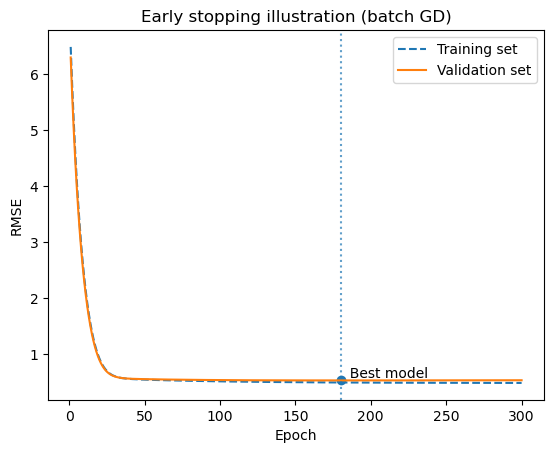

In [21]:
import matplotlib.pyplot as plt

epochs = np.arange(1, max_epochs + 1)

best_epoch = np.argmin(val_rmse) + 1
best_rmse  = val_rmse[best_epoch - 1]

plt.figure()
plt.plot(epochs, train_rmse, linestyle="--", label="Training set")
plt.plot(epochs, val_rmse, label="Validation set")

# Mark best model
plt.axvline(best_epoch, linestyle=":", alpha=0.7)
plt.scatter([best_epoch], [best_rmse])
plt.text(best_epoch, best_rmse, "  Best model", va="bottom")

plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.legend()
plt.title("Early stopping illustration (batch GD)")
plt.show()


Help from [ChatGPT](https://chatgpt.com/share/6910bb34-a3c0-8008-9778-c5d62dfb35d6)

### Qe Conclusion

In this lesson, we learned how learning curves can be used to understand model performance and generalization. We learned how to identify underfitting, overfitting and the optimal capacity of a model, by analyzing the generalization gap between training and test errors. The concept of the generalization gap helped us measure how well a model performs on unseen data. By using techniques such as early stopping, we can reduce overfitting and make sure our model is able to generalize.

## L09: Hyperparameters and Gridsearch 

When instantiating a Scikit-learn model in python most or all constructor parameters have _default_ values. These values are not part of the internal model and are hence called ___hyperparameters___---in contrast to _normal_ model parameters, for example the neuron weights, $\mathbf w$, for an `MLP` model.

### Manual Tuning Hyperparameters

Below is an example of the python constructor for the support-vector classifier `sklearn.svm.SVC`, with say the `kernel` hyperparameter having the default value `'rbf'`. If you should choose, what would you set it to other than `'rbf'`? 

```python
class sklearn.svm.SVC(
    C=1.0, 
    kernel=’rbf’, 
    degree=3,
    gamma=’auto_deprecated’, 
    coef0=0.0, 
    shrinking=True, 
    probability=False, 
    tol=0.001, 
    cache_size=200, 
    class_weight=None, 
    verbose=False, 
    max_iter=-1, 
    decision_function_shape=’ovr’, 
    random_state=None
  )
```  

The default values might be a sensible general starting point, but for your data, you might want to optimize the hyperparameters to yield a better result. 

To be able to set `kernel` to a sensible value you need to go into the documentation for the `SVC` and understand what the kernel parameter represents, and what values it can be set to, and you need to understand the consequences of setting `kernel` to something different than the default...and the story repeats for every other hyperparameter!

### Brute Force  Search

An alternative to this structured, but time-consuming approach, is just to __brute-force__ a search of interesting hyperparameters, and  choose the 'best' parameters according to a fit-predict and some score, say 'f1'. 

<img src="https://itundervisning.ase.au.dk/SWMAL/L09/Figs/gridsearch.png"  alt="WARNING: could not get image from server."  style="width:350px">
<small><em>
    <center> Conceptual graphical view of grid search for two distinct hyperparameters. </center> 
    <center> Notice that you would normally search hyperparameters like `alpha` with an exponential range, say [0.01, 0.1, 1, 10] or similar.</center>
</em></small>

Now, you just pick out some hyperparameters, that you figure are important, set them to a suitable range, say

```python
    'kernel':('linear', 'rbf'), 
    'C':[1, 10]
```
and fire up a full (grid) search on this hyperparameter set, that will try out all your specified combination of `kernel` and `C` for the model, and then prints the hyperparameter set with the highest score...

The demo code below sets up some of our well known 'hello-world' data and then run a _grid search_ on a particular model, here a _support-vector classifier_ (SVC)

Other models and datasets  ('mnist', 'iris', 'moon') can also be examined.

### Qa Explain GridSearchCV

There are two code cells below: 1) function setup, 2) the actual grid-search.

Review the code cells and write a __short__ summary. Mainly focus on __cell 2__, but dig into cell 1 if you find it interesting (notice the use of local-function, a nifty feature in python).
  
In detail, examine the lines:  
  
```python
grid_tuned = GridSearchCV(model, tuning_parameters, ..
grid_tuned.fit(X_train, y_train)
..
FullReport(grid_tuned , X_test, y_test, time_gridsearch)
```
and write a short description of how the `GridSeachCV` works: explain how the search parameter set is created and the overall search mechanism is functioning (without going into too much detail).

What role does the parameter `scoring='f1_micro'` play in the `GridSearchCV`, and what does `n_jobs=-1` mean? 

##### GridSearchCV
How GridSearchCV works is by defining a grid of what we call hyperparameters and then it systematically trains and evaluates an ML model for each hyperparameter combination. When we train and evaluate the models for each combination, we call it cross-validation. This is because we select the best set of parameters based on our performance metric.

##### Cell 2
As cell 2 is the most interesting cell to us, we have decided to review this.
We start by loading the data using the function "SearchReport" and setting up an SVM classifier with a gamma value of 0.001 gamma. We run the search with the "cv" parameter with a value of 5, meaning we split the data into 5 folds, scoring with f1_micro.

We use this scoring metric to select the best hyperparameters during the search. It balances precision and recall with the following formulas:

precision = TP / (TP + FP)
recall = TP / (TP + FN)

Where finally, we get:
F1 = 2 * (precision * recall) / (precision + recall)

For F1 Micro though, we compute the parameters TP, FP and FN by summin over all classes and then computes the precision, the recall and the F1 from those given totals. We use F1 Micro when we care for overall correctness in terms of samples.

When we use n_jobs=-1, we use all available CPU cores, which can increase memory use. Setting it to None or 1 means that we run serially, and setting it to n_jobs>1 means we use X amount of parallel jobs.

In [16]:
# TODO: Qa, code review..cell 1) function setup

from time import time
import numpy as np
import sys
sys.path.append('../Opgave1') # to load libitmal

from sklearn import svm
from sklearn.linear_model import SGDClassifier

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.metrics import classification_report, f1_score
from sklearn import datasets

from libitmal import dataloaders as itmaldataloaders # Needed for load of iris, moon and mnist

currmode="N/A" # GLOBAL var!

def SearchReport(model): 
    
    def GetBestModelCTOR(model, best_params):
        def GetParams(best_params):
            ret_str=""          
            for key in sorted(best_params):
                value = best_params[key]
                temp_str = "'" if str(type(value))=="<class 'str'>" else ""
                if len(ret_str)>0:
                    ret_str += ','
                ret_str += f'{key}={temp_str}{value}{temp_str}'  
            return ret_str          
        try:
            param_str = GetParams(best_params)
            return type(model).__name__ + '(' + param_str + ')' 
        except:
            return "N/A(1)"
        
    print("\nBest model set found on train set:")
    print()
    print(f"\tbest parameters={model.best_params_}")
    print(f"\tbest '{model.scoring}' score={model.best_score_}")
    print(f"\tbest index={model.best_index_}")
    print()
    print(f"Best estimator CTOR:")
    print(f"\t{model.best_estimator_}")
    print()
    try:
        print(f"Grid scores ('{model.scoring}') on development set:")
        means = model.cv_results_['mean_test_score']
        stds  = model.cv_results_['std_test_score']
        i=0
        for mean, std, params in zip(means, stds, model.cv_results_['params']):
            print("\t[%2d]: %0.3f (+/-%0.03f) for %r" % (i, mean, std * 2, params))
            i += 1
    except:
        print("WARNING: the random search do not provide means/stds")
    
    global currmode                
    assert "f1_micro"==str(model.scoring), f"come on, we need to fix the scoring to be able to compare model-fits! Your scoreing={str(model.scoring)}...remember to add scoring='f1_micro' to the search"   
    return f"best: dat={currmode}, score={model.best_score_:0.5f}, model={GetBestModelCTOR(model.estimator,model.best_params_)}", model.best_estimator_ 

def ClassificationReport(model, X_test, y_test, target_names=None):
    assert X_test.shape[0]==y_test.shape[0]
    print("\nDetailed classification report:")
    print("\tThe model is trained on the full development set.")
    print("\tThe scores are computed on the full evaluation set.")
    print()
    y_true, y_pred = y_test, model.predict(X_test)                 
    print(classification_report(y_true, y_pred, target_names=target_names))
    print()
    
def FullReport(model, X_test, y_test, t):
    print(f"SEARCH TIME: {t:0.2f} sec")
    beststr, bestmodel = SearchReport(model)
    ClassificationReport(model, X_test, y_test)    
    print(f"CTOR for best model: {bestmodel}\n")
    print(f"{beststr}\n")
    return beststr, bestmodel
    
def LoadAndSetupData(mode, test_size=0.3):
    assert test_size>=0.0 and test_size<=1.0
    
    def ShapeToString(Z):
        n = Z.ndim
        s = "("
        for i in range(n):
            s += f"{Z.shape[i]:5d}"
            if i+1!=n:
                s += ";"
        return s+")"

    global currmode
    currmode=mode
    print(f"DATA: {currmode}..")
    
    if mode=='moon':
        X, y = itmaldataloaders.MOON_GetDataSet(n_samples=5000, noise=0.2)
        itmaldataloaders.MOON_Plot(X, y)
    elif mode=='mnist':
        X, y = itmaldataloaders.MNIST_GetDataSet(load_mode=0)
        if X.ndim==3:
            X=np.reshape(X, (X.shape[0], -1))
    elif mode=='iris':
        X, y = itmaldataloaders.IRIS_GetDataSet()
    else:
        raise ValueError(f"could not load data for that particular mode='{mode}', only 'moon'/'mnist'/'iris' supported")
        
    print(f'  org. data:  X.shape      ={ShapeToString(X)}, y.shape      ={ShapeToString(y)}')

    assert X.ndim==2
    assert X.shape[0]==y.shape[0]
    assert y.ndim==1 or (y.ndim==2 and y.shape[1]==0)    
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=0, shuffle=True
    )
    
    print(f'  train data: X_train.shape={ShapeToString(X_train)}, y_train.shape={ShapeToString(y_train)}')
    print(f'  test data:  X_test.shape ={ShapeToString(X_test)}, y_test.shape ={ShapeToString(y_test)}')
    print()
    
    return X_train, X_test, y_train, y_test

def TryKerasImport(verbose=True):
    
    kerasok = True
    try:
        import keras as keras_try
    except:
        kerasok = False

    tensorflowkerasok = True
    try:
        import tensorflow.keras as tensorflowkeras_try
    except:
        tensorflowkerasok = False
        
    ok = kerasok or tensorflowkerasok
    
    if not ok and verbose:
        if not kerasok:
            print("WARNING: importing 'keras' failed", file=sys.stderr)
        if not tensorflowkerasok:
            print("WARNING: importing 'tensorflow.keras' failed", file=sys.stderr)

    return ok
    
print(f"OK(function setup" + ("" if TryKerasImport() else ", hope MNIST loads works because it seems you miss the installation of Keras or Tensorflow!") + ")")

OK(function setup)


In [17]:
# TODO: Qa, code review..cell 2) the actual grid-search

# Setup data
X_train, X_test, y_train, y_test = LoadAndSetupData(
    'iris')  # 'iris', 'moon', or 'mnist'

# Setup search parameters
model = svm.SVC(
    gamma=0.001
)  # NOTE: gamma="scale" does not work in older Scikit-learn frameworks,
# FIX:  replace with model = svm.SVC(gamma=0.001)

tuning_parameters = {
    'kernel': ('linear', 'rbf'), 
    'C': [0.1, 1, 10]
}

CV = 5
VERBOSE = 0

# Run GridSearchCV for the model
grid_tuned = GridSearchCV(model,
                          tuning_parameters,
                          cv=CV,
                          scoring='f1_micro',
                          verbose=VERBOSE,
                          n_jobs=-1)

start = time()
grid_tuned.fit(X_train, y_train)
t = time() - start

# Report result
b0, m0 = FullReport(grid_tuned, X_test, y_test, t)
print('OK(grid-search)')

DATA: iris..
  org. data:  X.shape      =(  150;    4), y.shape      =(  150)
  train data: X_train.shape=(  105;    4), y_train.shape=(  105)
  test data:  X_test.shape =(   45;    4), y_test.shape =(   45)

SEARCH TIME: 1.95 sec

Best model set found on train set:

	best parameters={'C': 1, 'kernel': 'linear'}
	best 'f1_micro' score=0.9714285714285715
	best index=2

Best estimator CTOR:
	SVC(C=1, gamma=0.001, kernel='linear')

Grid scores ('f1_micro') on development set:
	[ 0]: 0.962 (+/-0.093) for {'C': 0.1, 'kernel': 'linear'}
	[ 1]: 0.371 (+/-0.038) for {'C': 0.1, 'kernel': 'rbf'}
	[ 2]: 0.971 (+/-0.047) for {'C': 1, 'kernel': 'linear'}
	[ 3]: 0.695 (+/-0.047) for {'C': 1, 'kernel': 'rbf'}
	[ 4]: 0.952 (+/-0.085) for {'C': 10, 'kernel': 'linear'}
	[ 5]: 0.924 (+/-0.097) for {'C': 10, 'kernel': 'rbf'}

Detailed classification report:
	The model is trained on the full development set.
	The scores are computed on the full evaluation set.

              precision    recall  f1-score  

### Qb Hyperparameter Grid Search using an SDG classifier


In [18]:
# Setup data
X_train, X_test, y_train, y_test = LoadAndSetupData('iris') # 'iris', 'moon', or 'mnist'

# Setup search parameters
model = SGDClassifier(random_state=42)

tuning_parameters = {
    'loss': ('hinge', 'log_loss', 'modified_huber'),
    'alpha': [0.0001, 0.001, 0.01],
    'penalty': ['l2', 'l1', 'elasticnet'],
    'max_iter': [1000, 2000],
}

CV = 5
VERBOSE = 0

# Run GridSearchCV for the model
grid_tuned = GridSearchCV(model,
                          tuning_parameters,
                          cv=CV,
                          scoring='f1_micro',
                          verbose=VERBOSE,
                          n_jobs=-1)

start = time()
grid_tuned.fit(X_train, y_train)
t = time() - start

# Report result
b0, m0 = FullReport(grid_tuned, X_test, y_test, t)
print('OK(grid-search-sgd)')

DATA: iris..
  org. data:  X.shape      =(  150;    4), y.shape      =(  150)
  train data: X_train.shape=(  105;    4), y_train.shape=(  105)
  test data:  X_test.shape =(   45;    4), y_test.shape =(   45)

SEARCH TIME: 0.09 sec

Best model set found on train set:

	best parameters={'alpha': 0.01, 'loss': 'log_loss', 'max_iter': 1000, 'penalty': 'l1'}
	best 'f1_micro' score=0.9714285714285713
	best index=43

Best estimator CTOR:
	SGDClassifier(alpha=0.01, loss='log_loss', penalty='l1', random_state=42)

Grid scores ('f1_micro') on development set:
	[ 0]: 0.895 (+/-0.111) for {'alpha': 0.0001, 'loss': 'hinge', 'max_iter': 1000, 'penalty': 'l2'}
	[ 1]: 0.819 (+/-0.304) for {'alpha': 0.0001, 'loss': 'hinge', 'max_iter': 1000, 'penalty': 'l1'}
	[ 2]: 0.819 (+/-0.194) for {'alpha': 0.0001, 'loss': 'hinge', 'max_iter': 1000, 'penalty': 'elasticnet'}
	[ 3]: 0.895 (+/-0.111) for {'alpha': 0.0001, 'loss': 'hinge', 'max_iter': 2000, 'penalty': 'l2'}
	[ 4]: 0.819 (+/-0.304) for {'alpha': 0.0001

### Qc Hyperparameter Random  Search using an SDG classifier

In [6]:
X_train, X_test, y_train, y_test = LoadAndSetupData('iris')

model = SGDClassifier(random_state=42)

tuning_parameters = {
    'loss': ['hinge', 'log_loss', 'modified_huber'],
    'alpha': [0.0001, 0.001, 0.01],
    'penalty': ['l2', 'l1', 'elasticnet'],
    'max_iter': [1000, 2000],
}

CV = 5
VERBOSE = 0

# randomized search
random_tuned = RandomizedSearchCV(
    model,
    tuning_parameters,
    n_iter=20,
    random_state=42,
    cv=CV,
    scoring='f1_micro',
    verbose=VERBOSE,
    n_jobs=-1
)

start = time()
random_tuned.fit(X_train, y_train)
t_random = time() - start

# result
b1, m1 = FullReport(random_tuned, X_test, y_test, t_random)
print("OK(random-search)")

DATA: iris..
  org. data:  X.shape      =(  150;    4), y.shape      =(  150)
  train data: X_train.shape=(  105;    4), y_train.shape=(  105)
  test data:  X_test.shape =(   45;    4), y_test.shape =(   45)

SEARCH TIME: 0.06 sec

Best model set found on train set:

	best parameters={'penalty': 'l1', 'max_iter': 1000, 'loss': 'hinge', 'alpha': 0.01}
	best 'f1_micro' score=0.9619047619047618
	best index=16

Best estimator CTOR:
	SGDClassifier(alpha=0.01, penalty='l1', random_state=42)

Grid scores ('f1_micro') on development set:
	[ 0]: 0.943 (+/-0.071) for {'penalty': 'l1', 'max_iter': 1000, 'loss': 'hinge', 'alpha': 0.001}
	[ 1]: 0.952 (+/-0.000) for {'penalty': 'l1', 'max_iter': 1000, 'loss': 'modified_huber', 'alpha': 0.01}
	[ 2]: 0.886 (+/-0.214) for {'penalty': 'l2', 'max_iter': 1000, 'loss': 'modified_huber', 'alpha': 0.01}
	[ 3]: 0.819 (+/-0.258) for {'penalty': 'l2', 'max_iter': 1000, 'loss': 'modified_huber', 'alpha': 0.0001}
	[ 4]: 0.905 (+/-0.181) for {'penalty': 'elasticne

#### Answer Qc
When using the _RandomizedSearchCV_, instead of testing all combinations of the parameters, we only "pull out" and test random combinations of the parameters.  
The added _n-iter_ variable is where we define how many random combinations we want to evaluate, and the _random-state_ makes the search reproduceible.  
In large datasets this would obviously result in a much faster runtime, but the chances of finding the *most* optimal combination will decrease. 

Comparing the grid search with the random search, we see that the _f1-micro_ score is higher for the grid search: 0.9714 vs. 0.9619.  
This is expected, as randomSearch only evalueates a subset of the searching space.
Further, when comparing the "best parameters", the two methods finds the same _alpha_, _penalty_ and _max-iter_. So _randomSearch_ finds three of four hyper parameters as _gridSearch_ did, which  
means _randomSearch_ was close to hitting the optimal combination. 

So, to conclude, _GridSearch_ found the best combination by testing them all, and _RandomSearch_ found a "good but not perfect" combination.

_This task has been solved with help from ChatGPT 5.1, which has helped with the code. See reference in the bottom of this markdown. The answer has been written from own observations._

### Qd MNIST Search Quest II

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV
from time import time

X_train, X_test, y_train, y_test = LoadAndSetupData('mnist')

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

model = LogisticRegression(
    solver='saga',
    multi_class='multinomial',
    n_jobs=-1,
    max_iter=200
)

tuning_parameters = {
    'C': [0.5, 1, 2],
}

random_tuned = RandomizedSearchCV(
    model,
    tuning_parameters,
    n_iter=3,
    cv=3,
    scoring='f1_micro',
    verbose=1,
    n_jobs=-1
)

start = time()
random_tuned.fit(X_train, y_train)
dt = time() - start

b1, m1 = FullReport(random_tuned, X_test, y_test, dt)
print(b1)

DATA: mnist..
  org. data:  X.shape      =(70000;  784), y.shape      =(70000)
  train data: X_train.shape=(49000;  784), y_train.shape=(49000)
  test data:  X_test.shape =(21000;  784), y_test.shape =(21000)

Fitting 3 folds for each of 3 candidates, totalling 9 fits


/Users/danielthem/miniforge3/envs/myenv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/danielthem/miniforge3/envs/myenv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/danielthem/miniforge3/envs/myenv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/danielthem/miniforge3/envs/myenv/lib/python3.10/sit

SEARCH TIME: 407.03 sec

Best model set found on train set:

	best parameters={'C': 1}
	best 'f1_micro' score=0.9170000265858799
	best index=1

Best estimator CTOR:
	LogisticRegression(C=1, max_iter=200, multi_class='multinomial', n_jobs=-1,
                   solver='saga')

Grid scores ('f1_micro') on development set:
	[ 0]: 0.917 (+/-0.005) for {'C': 0.5}
	[ 1]: 0.917 (+/-0.005) for {'C': 1}
	[ 2]: 0.917 (+/-0.005) for {'C': 2}

Detailed classification report:
	The model is trained on the full development set.
	The scores are computed on the full evaluation set.

              precision    recall  f1-score   support

           0       0.96      0.97      0.97      2077
           1       0.94      0.97      0.95      2385
           2       0.92      0.90      0.91      2115
           3       0.92      0.88      0.90      2117
           4       0.89      0.94      0.92      2004
           5       0.88      0.87      0.88      1900
           6       0.93      0.95      0.94     

/Users/danielthem/miniforge3/envs/myenv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In Qd, "_saga_" has been used, which uses logistic regression. Afterwards RandomizedSearch has been used, as gridSearch would take too long on MNIST. This task took forever on my machine, probably not an optimal environment I have...  

We manage to get f1_micro = 0.9170

_This task has been solved with help from ChatGPT 5.1, which has helped with the code. See reference in the bottom of this markdown. The answer has been written from own observations._

## L10: Sprogmodeller/NanoGPT

# Qa — Journaling the NanoGPT hands-on

## Introduction
This journal explains the exercise regarding the training and evaluation of a small GPT-style model (NanoGPT) on the H.C. Andersen character dataset (`dataset='hca'`). The objective was to execute a simple loop—**prepare → train → predict → tune**—and relate console outputs to core ML concepts including iterations, losses, the optimizer, the learning-rate schedule, and model capacity.


## Setup and data
After `make install`, the plain-text dataset hca was used. During training, the text was segmented into fixed-length windows (`block_size=256`). Each window served as an input sequence, and the label at each position was the next character, following standard next-token prediction. In this framing, the batch of windows constitutes the design matrix **X**, while the targets **y** are the same windows shifted forward by one character.


## Training
Training started with make train. On each step the model read a batch (X), tried to guess the next character, measured how wrong it was (cross-entropy vs. the true next characters y), and then updated its weights with AdamW. Every so often it checked performance on a separate validation set and printed lines like:

```
iter 1200: train loss 4.8, val loss 4.8
```

 Decreases in training and validation losses indicate learning of useful patterns. A continued decrease in training loss accompanied by stagnant or rising validation loss indicates overfitting, warranting early stopping or additional regularization.


## Prediction
Generation was conducted via `make pred` which internally is `sample.py` but the command overrides some of the configs at default importantly a short prompt and a chosen **temperature**.


## Configuration

From `config/train_hca.py`:

```python
gradient_accumulation_steps = 1
batch_size = 64
block_size = 256     # context window

n_layer = 3
n_head  = 3
n_embd  = 192
dropout = 0.2

learning_rate = 1e-3
max_iters     = 5000
lr_decay_iters= 5000
min_lr        = 1e-4
beta2         = 0.99
warmup_iters  = 100
```

Here, `batch_size=64` defines the number of windows per iteration, and `gradient_accumulation_steps=1` specifies one update per batch (higher values emulate larger effective batch sizes under memory constraints). `block_size=256` sets the visible context during training and limits prompt length during inference. The tuple `n_layer`, `n_head`, and `n_embd` specifies depth, attention heads, and embedding width; `dropout=0.2` randomly disables activations to mitigate overfitting. Optimization employs **AdamW** with base `learning_rate=1e-3`, a `beta2=0.99` variance estimate smoother, and `warmup_iters=100` for a gradual ramp-up. After warmup, the learning rate decays over `lr_decay_iters=5000` toward `min_lr=1e-4`, typically with a cosine schedule. `max_iters=5000` caps the update count.


## Observations
The model quickly picked up short patterns (letters and short phrases). When we kept training after the validation score stopped improving, it started to overfit and repeat itself. Output quality was decided on how coherent the text was. Temperatures around 0.6–0.8 worked well.

### Qb Explaining some of the details of LLM training and prediction

Temperature controls sampling randomness which means values below 1.0 tended to be safer but more repetitive while values near 1.0 offered a balanced trade-off. The design matrix X is just batches of text slices of the same length (block_size). The labels y are the same slices shifted by one character/token so the model learns the “next token.” The test labels (y_test) are built the same way on a held-out set and used once to report a final score (like test perplexity). Prompting is how we guide the model: we put instructions or examples in the input so it continues in that style.

## Our own data

For our own data, we merged all Katrines Kælder meeting summaries into a file we called `merged.txt` which consisted of 1.34M characters. 

# Training

We started out by using the exact same default config and makefile as the hca with max_iters=1000 which gave the following results:


```console
step 1000: train loss 1.4891, val loss 1.6295

saving checkpoint to out-ref

iter 1000: loss 1.7164, time 2312.39ms, mfu 3.40%
```

We can see that the training of the model is already good as both train and validation losses have fallen to ~1.49 and ~1.63 which indicates solid learning and no clear overfitting at 1,000 steps.

### Example predction 1

We then tried to make a prediction again with the default values except we changed the start to Dagsorden: as we felt it might yield more coherent results:

```console
swmal10e25@node6:~/GITMAL/L10/NanoGPT$ make pred
/opt/anaconda-2024.02/bin/python3 sample.py --out_dir=out-ref --temperature=0.2 --num_samples=2 --start="Dagsorden:"
SELECTED device 'cuda:1' with free mem 11811 MiB out of total 2 GPUs
Overriding: out_dir = out-ref
Overriding: temperature = 0.2
Overriding: num_samples = 2
Overriding: start = Dagsorden:
number of parameters: 1.35M
Loading meta from data/ref/meta.pkl...
  start=Dagsorden:, temperature=0.2..
BEG 0 --------------------------------
Dagsorden: 
        •       Skyldnere med bartendere en skal være bestyrelsesmøde i Katrines Kælder 
        •       Skyldnere med til bartendere 
        •       Bestyrelsesmøde i Katrines Kælder 
        •       Stormøde i Katrines Kælder 
        •       Mads Kælder 
        •       Skyldnere med til bestyrelsesmøde i Katrines Kælder 
        •       Skyldnere i Katrines Kælder i Katrines Kælder 
        •       Skrives til bestyrelsesmøde i Katrines Kælder 
        •       Kommer indkaldes Kælder 
        •       Skyldnere møde i Katrines Kælder i Katrines Kælder 
        •       Skyldnere møde i Katrines Kælder 
        •       Mandste møde i Katrines K
END 0 --------------------------------
BEG 1 --------------------------------
Dagsorden: 
        •       Der er skal være skal være stå stormøde. 
        •       Det er er er skal står skal være skal være skal være stopper på det er skal være studen at skal være skal være skal være med at så stå det er skal stå med at være står skal stå for at det står det er skal være skal være semestemning af der er skal være at skal kan være have skal være står med at det skal være at være skal være for at have skal være skal være op til det er skal være skal være en skal være samle semestemning af det skal skal være
```

### Example predction 2

We then tried to tweak the model a bit by chaning the temperature to 0.9, the top_k to 50 and made the prombt a little more open which resulted in this:

```console swmal10e25@node6:~/GITMAL/L10/NanoGPT$ make pred
/opt/anaconda-2024.02/bin/python3 sample.py --out_dir=out-ref --temperature=0.9 --num_samples=2 --start="Referat:"
SELECTED device 'cuda:1' with free mem 11811 MiB out of total 2 GPUs
Overriding: out_dir = out-ref
Overriding: temperature = 0.9
Overriding: num_samples = 2
Overriding: start = Referat:
number of parameters: 1.35M
Loading meta from data/ref/meta.pkl...
  start=Referat:, temperature=0.9..
BEG 0 --------------------------------
Referat: Brætspilst reventsbartender 
        •       Fadøleskal være alkoholdeskender opdater
opdater på til opsAnsvars det nye flow - nummer har i fra kan ikke skilt nye i være skilt uden lok fler gangerne.
        •       Arbejdsdag i ved til hvad skal lavet decene ved starte i gamle der på tender sigener os fra med at vasken få og alkoholdnat, en menge blave op. 
        •       Vi har nu, så blevet selvor nye velkommer (sen gruppers num andre fra herne til ny)
        •       Camil mobid baren ing i kortendermøde
        •       Events signes 
        •       Efternt
        •       Best
END 0 --------------------------------
BEG 1 --------------------------------
Referat: JNH, JRN vi fremmødte med til næste (med JRN)
        •       JRN har vi have et i bartendere for med JH færdig til hundere bartendermøde
        •       MKE i KK-Secialt til bartendermøde møde 5 ARH, MSK
        •       Findkaldermøde møde
```

While not a whole lot better it certainly reduced the amount of repetetive words in the text. We also made a small test increasing the max_iters to 10000 but this just made the model completely overfit and be even more repetetive and stagnant.

## Conclusion
This hands-on showed the basic language-model loop in practice and how to read it. Watching training and validation loss tells you when the model is learning and when to stop. On our own meeting-minutes data, the model improved quickly (good validation loss at 1k steps) but low-temperature sampling and very long training pushed it into repetitive bullet lists. Switching to a more neutral prompt (“Referat:”), using a moderate temperature (≈0.8–1.0) with an effective top-k (≈50), and stopping when validation stopped improving produced clearly better text.
## Sources

- [NanoGPT (GitHub)](https://github.com/karpathy/nanoGPT)
- [Attention Is All You Need (Transformer)](https://arxiv.org/abs/1706.03762)
- [Decoupled Weight Decay Regularization (AdamW)](https://arxiv.org/abs/1711.05101)
- [SGDR: Stochastic Gradient Descent with Warm Restarts](https://arxiv.org/abs/1608.03983)
- [The Curious Case of Neural Text Degeneration (nucleus sampling)](https://arxiv.org/abs/1904.09751)
- [Language Models are Few-Shot Learners (GPT-3)](https://arxiv.org/abs/2005.14165)
- [Hugging Face: Generation strategies](https://huggingface.co/docs/transformers/en/generation_strategies)
- **SWMAL Lesson 10 slides**
- Loukides, M. **What Are ChatGPT and Its Friends? (Pdf)**

### L09 Qc + Qd references:

#### Qc:

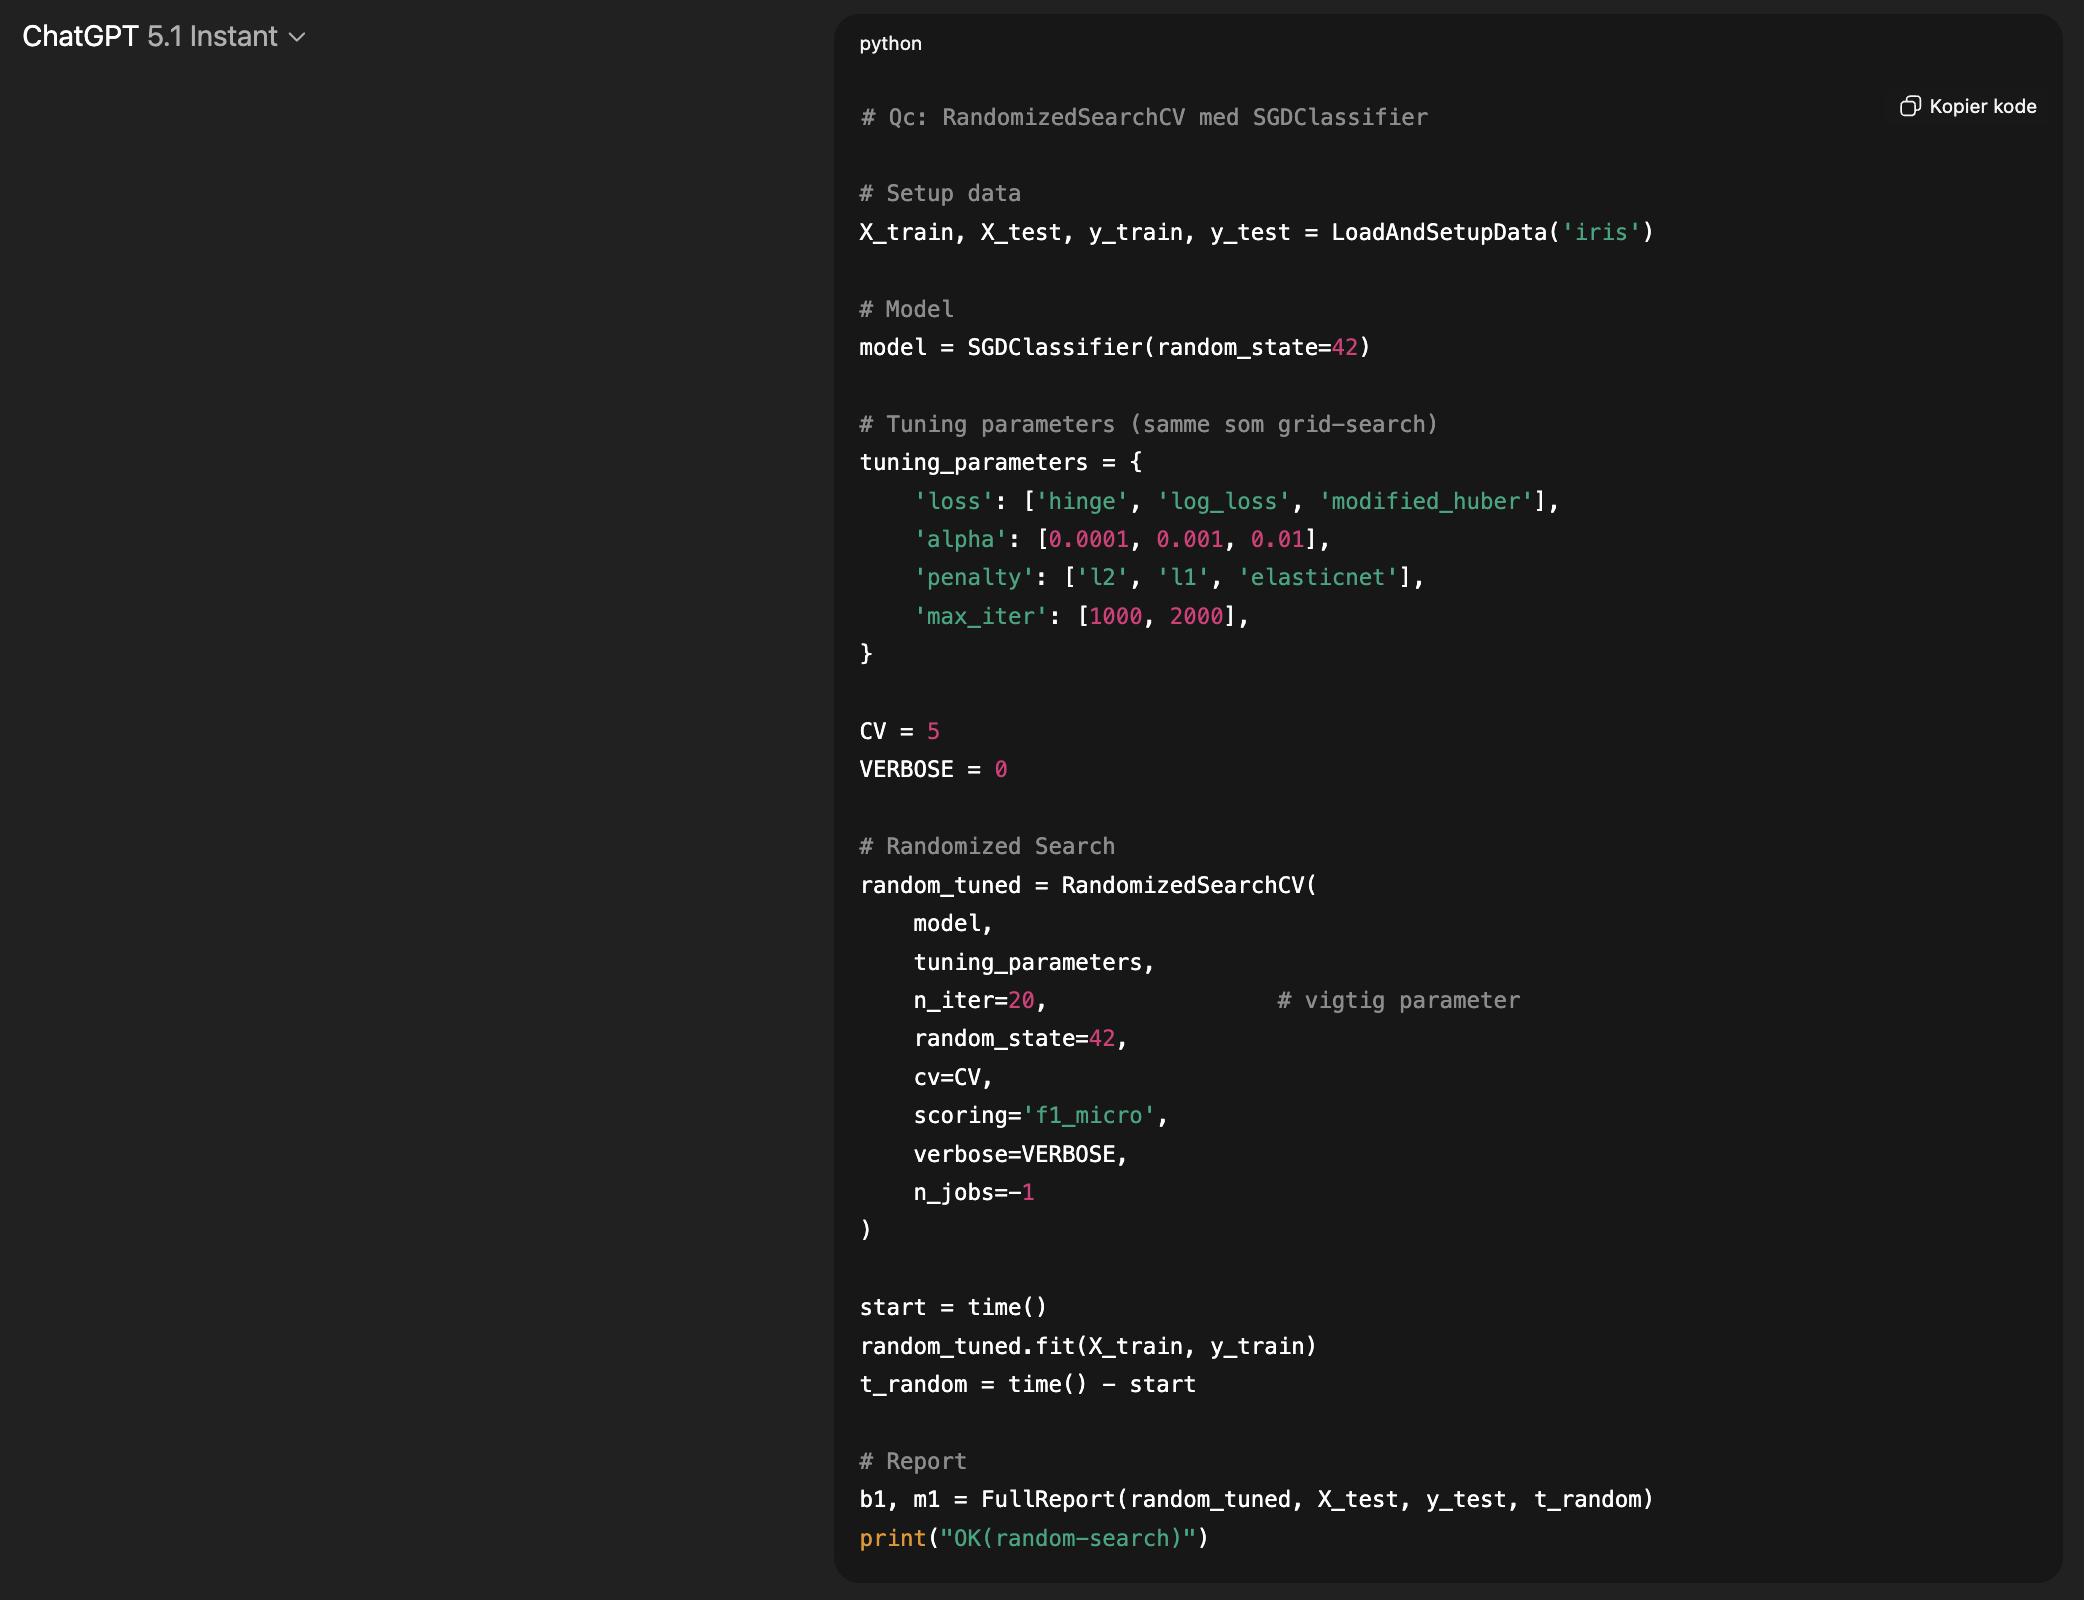

#### Qd:

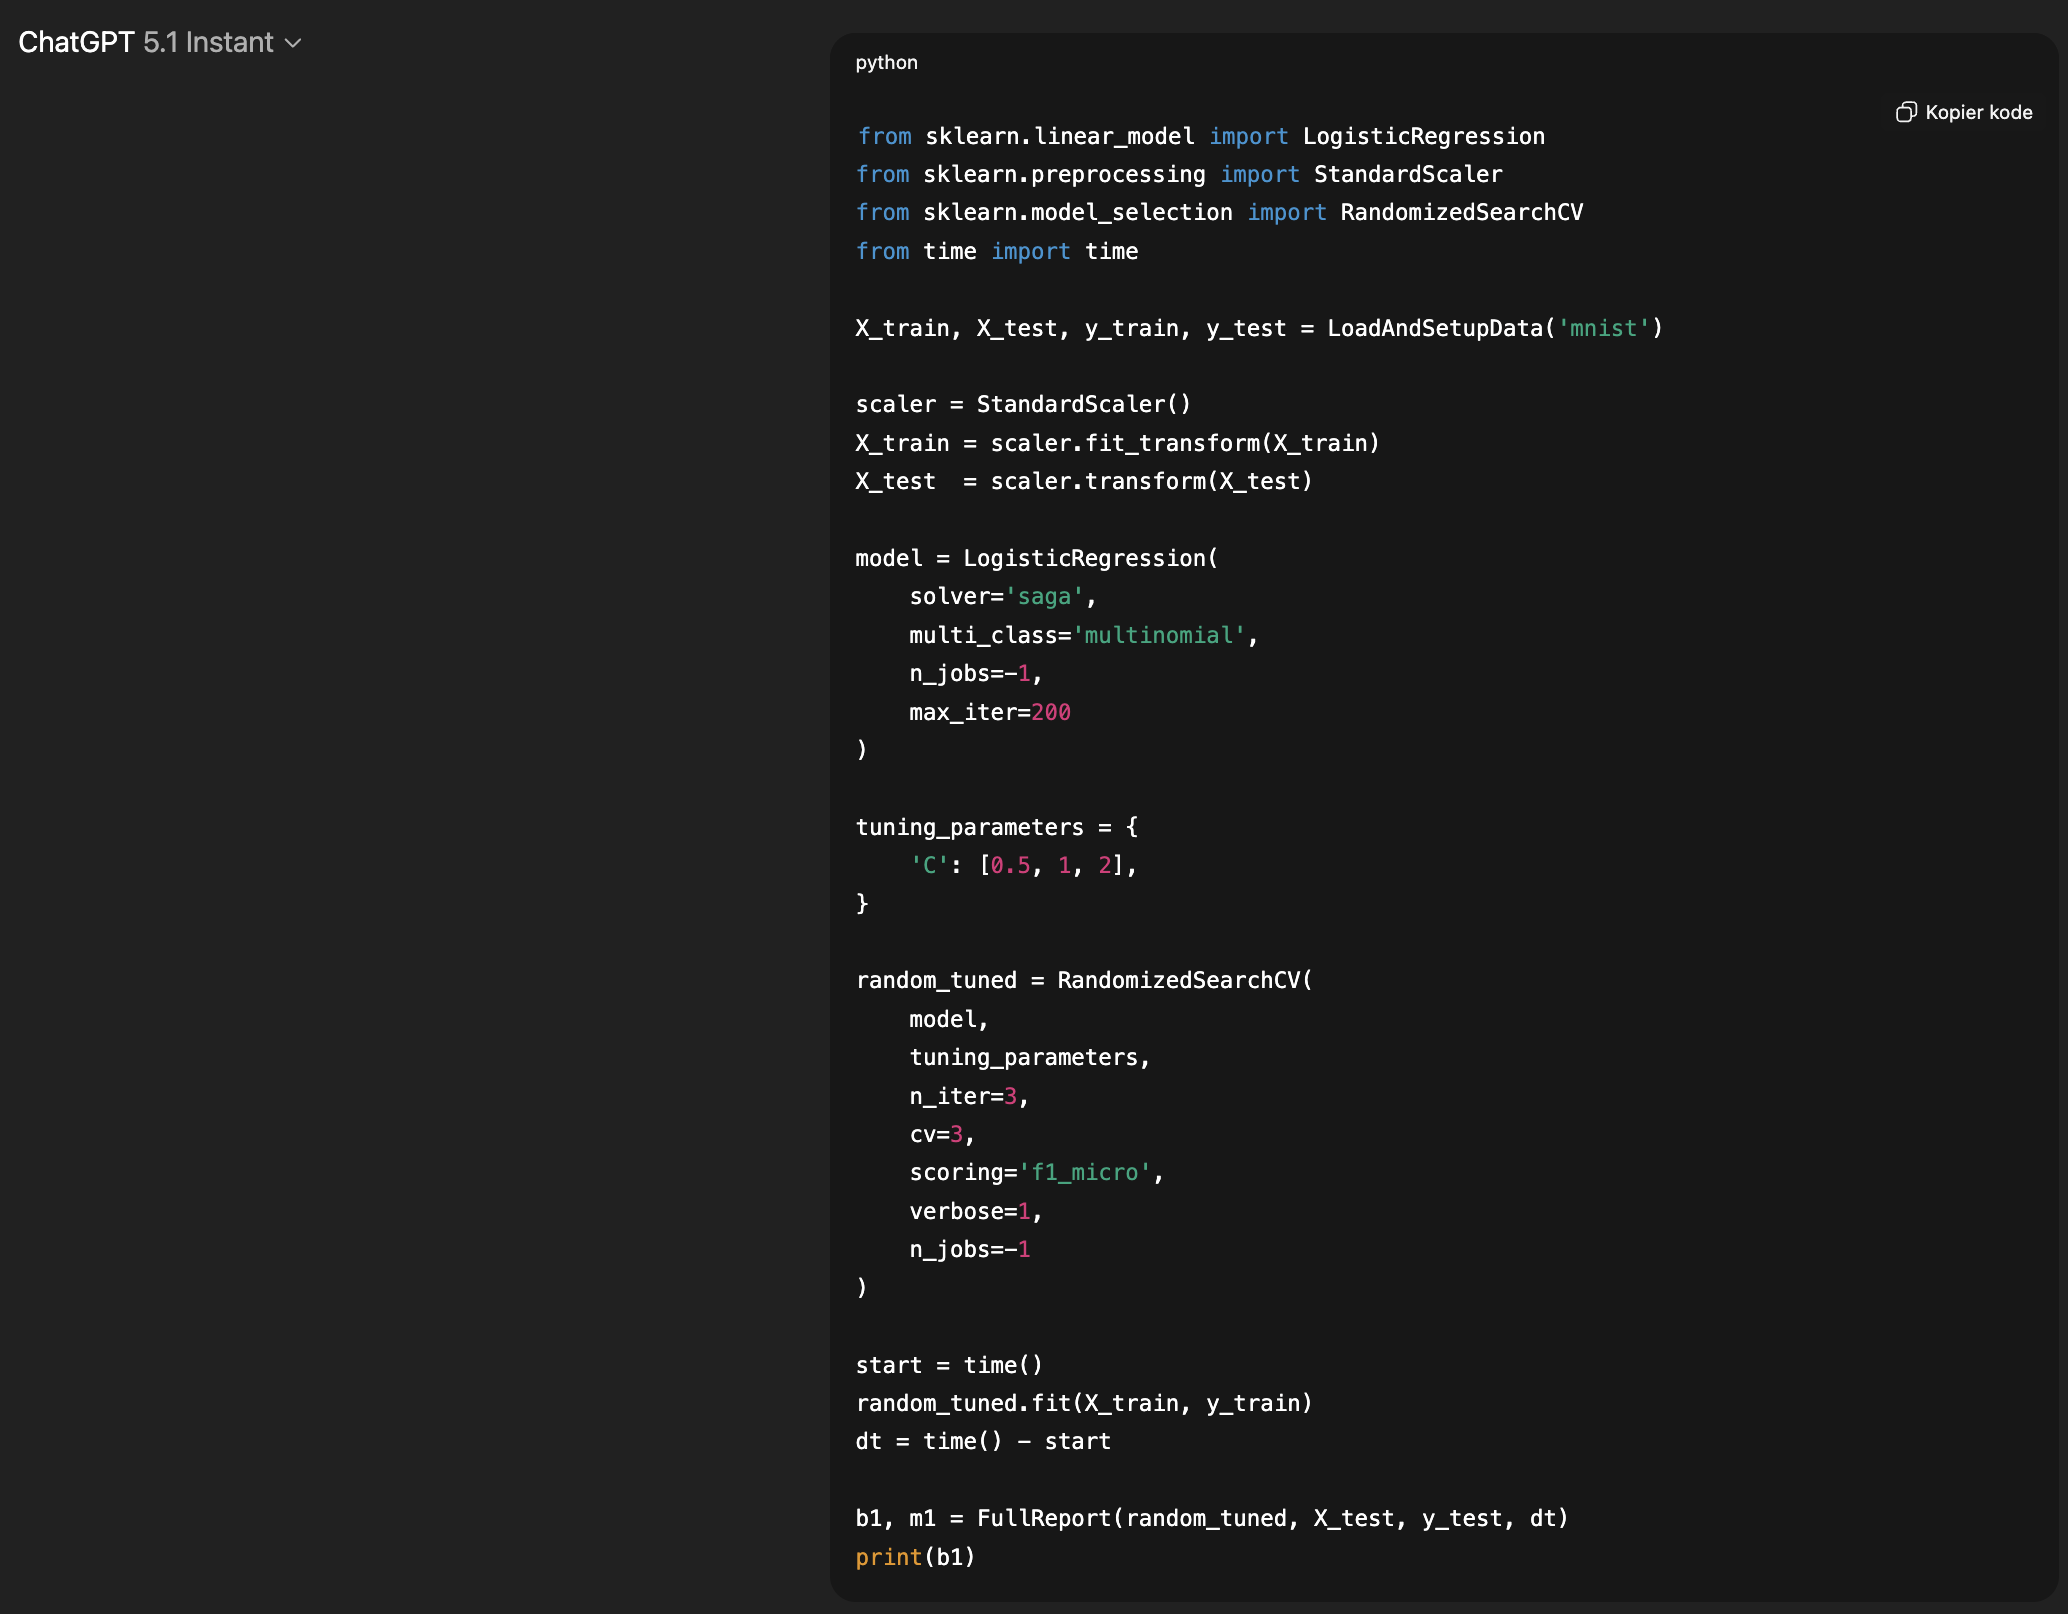
